In [1]:
import os
import re
import json
import logging
import nltk
from pathlib import Path
from dataclasses import dataclass
from typing import List, Tuple

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

2026-05-09 21:08:54.890395: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778360935.123128      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778360935.189994      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778360935.737738      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778360935.737773      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778360935.737776      22 computation_placer.cc:177] computation placer alr

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [4]:
for corpus in ['stopwords', 'wordnet', 'omw-1.4']:
    try:
        nltk.data.find(f'corpora/{corpus}')
    except LookupError:
        nltk.download(corpus, quiet=True)

In [5]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [6]:
class Config:
    MAX_SEQUENCE_LENGTH = 60
    VOCAB_SIZE = 6000
    EMBEDDING_DIM = 120
    LSTM_UNITS = 300
    SPATIAL_DROPOUT_RATE = 0.8
    DROPOUT_RATE = 0.5
    RECURRENT_DROPOUT_RATE = 0.5
    BATCH_SIZE = 50
    EPOCHS = 25
    TEST_SPLIT = 0.15                      # 15% for Test Set
    VAL_SPLIT = 0.176                      # 0.176 of Remaining 85% ≈ 15% of Total
    RANDOM_SEED = 42
    EARLY_STOPPING_PATIENCE = 10

    RISK_LABELS = {
        0: "no_risk",
        1: "low_risk",
        2: "high_risk",
    }
    LABEL_TO_ID = {v: k for k, v in RISK_LABELS.items()}

    KAGGLE_WORKING_DIR = Path("/kaggle/working/ML/Artifacts")
    MODELS_DIR = KAGGLE_WORKING_DIR / "Models"
    MODEL_PATH = MODELS_DIR / "bilstm_model.keras"
    TOKENIZER_PATH = MODELS_DIR / "tokenizer.json"
    LABEL_ENCODER_PATH = MODELS_DIR / "label_encoder.json"
    THRESHOLDS_PATH = MODELS_DIR / "thresholds.json"

In [7]:
@dataclass
class PreparedData:
    X: np.ndarray
    y: np.ndarray
    tokenizer: Tokenizer
    label_encoder: LabelEncoder

In [8]:
TOKEN_PATTERN = re.compile(r"[^a-zA-Z0-9\s]")

In [9]:
def clean_text(text: str) -> str:
    # Remove URLs
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    # Remove HTML tags
    text = re.sub(r"<[^>]+>", " ", text)
    # Remove @mentions
    text = re.sub(r"@\w+", " ", text)
    # Remove Hashtag Symbols but Keep the Word
    text = re.sub(r"#", " ", text)

    text = text.lower()
    text = TOKEN_PATTERN.sub(" ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)

In [10]:
def load_dataset(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    text_col = "tweet" if "tweet" in df.columns else "text"
    label_col = "category" if "category" in df.columns else "label"

    if text_col not in df.columns or label_col not in df.columns:
        raise ValueError(f"CSV Must Contain text/tweet and label/category Columns. Found: {df.columns}")

    df = df.dropna(subset=[text_col])

    df = df.rename(columns={text_col: "text", label_col: "label"})

    print(f"Loaded {len(df)} rows. Cleaning text...")
    df["text"] = df["text"].astype(str).map(clean_text)

    def normalize_label(value):
        if pd.isna(value): return None
        try:
            numeric = int(value)
            if numeric in Config.RISK_LABELS: return Config.RISK_LABELS[numeric]
        except (TypeError, ValueError):
            pass
        if isinstance(value, str):
            label = value.strip().lower()
            if label in Config.LABEL_TO_ID: return label
        return None

    df["label"] = df["label"].map(normalize_label)
    df = df.dropna(subset=["label"])
    print(f"Remaining valid rows after cleaning: {len(df)}")

    # Print Class Distribution
    print(f"\nClass Distribution:")
    for label, count in df["label"].value_counts().items():
        print(f"  {label}: {count} ({count / len(df) * 100:.1f}%)")

    return df

In [11]:
def encode_labels(labels: List[str]) -> Tuple[np.ndarray, LabelEncoder]:
    encoder = LabelEncoder()
    classes = [Config.RISK_LABELS[idx] for idx in sorted(Config.RISK_LABELS.keys())]
    encoder.classes_ = np.array(classes, dtype=object)
    label_to_id = {label: idx for idx, label in enumerate(encoder.classes_)}
    y = np.array([label_to_id[label] for label in labels], dtype=np.int32)
    return y, encoder

In [12]:
def prepare_data(csv_path: Path) -> PreparedData:
    df = load_dataset(csv_path)

    tokenizer = Tokenizer(num_words=Config.VOCAB_SIZE, oov_token="<OOV>")
    tokenizer.fit_on_texts(df["text"].tolist())

    sequences = tokenizer.texts_to_sequences(df["text"].tolist())
    X = pad_sequences(sequences, maxlen=Config.MAX_SEQUENCE_LENGTH, padding="post", truncating="post")

    y, label_encoder = encode_labels(df["label"].tolist())
    return PreparedData(X=X, y=y, tokenizer=tokenizer, label_encoder=label_encoder)

In [13]:
def build_model(num_classes: int) -> tf.keras.Model:
    inputs = tf.keras.layers.Input(shape=(Config.MAX_SEQUENCE_LENGTH,))
    x = tf.keras.layers.Embedding(
        input_dim=Config.VOCAB_SIZE,
        output_dim=Config.EMBEDDING_DIM,
        input_length=Config.MAX_SEQUENCE_LENGTH,
    )(inputs)
    x = tf.keras.layers.SpatialDropout1D(Config.SPATIAL_DROPOUT_RATE)(x)
    x = tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(
            Config.LSTM_UNITS,
            dropout=Config.DROPOUT_RATE,
            recurrent_dropout=Config.RECURRENT_DROPOUT_RATE,
        )
    )(x)
    x = tf.keras.layers.Dropout(Config.DROPOUT_RATE)(x)
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(64, activation="relu")(x)
    x = tf.keras.layers.Dropout(Config.DROPOUT_RATE)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

In [14]:
def evaluate_model(model, X_test, y_test, class_names):
    print("\n" + "=" * 60)
    print("          TEST SET EVALUATION")
    print("=" * 60)

    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Classification Rreport (Precision, Recall, F1 Per Class)
    report = classification_report(
        y_test, y_pred,
        target_names=class_names,
        digits=4,
        output_dict=False,
    )
    print(report)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(f"{'':>12}", end="")
    for name in class_names:
        print(f"{name:>12}", end="")
    print()
    for i, row in enumerate(cm):
        print(f"{class_names[i]:>12}", end="")
        for val in row:
            print(f"{val:>12}", end="")
        print()

    # Return the Dictionary Form for Programmatic Use
    report_dict = classification_report(
        y_test, y_pred,
        target_names=class_names,
        digits=4,
        output_dict=True,
    )

    print("\n" + "=" * 60)
    print(f"  Overall Accuracy:  {report_dict['accuracy']:.4f} ({report_dict['accuracy'] * 100:.2f}%)")
    print(f"  Macro Avg F1:      {report_dict['macro avg']['f1-score']:.4f}")
    print(f"  Weighted Avg F1:   {report_dict['weighted avg']['f1-score']:.4f}")
    print("=" * 60)

    return report_dict

In [15]:
def compute_optimal_thresholds(model, X_val, y_val, class_names):
    # Compute Per-Class Probability Thresholds that Maximize F1 on Validation Set
    y_pred_probs = model.predict(X_val, verbose=0)
    thresholds = {}

    for i, class_name in enumerate(class_names):
        best_f1 = 0.0
        best_thresh = 0.5
        for thresh in np.arange(0.1, 0.9, 0.05):
            y_binary_true = (y_val == i).astype(int)
            y_binary_pred = (y_pred_probs[:, i] >= thresh).astype(int)

            tp = np.sum((y_binary_pred == 1) & (y_binary_true == 1))
            fp = np.sum((y_binary_pred == 1) & (y_binary_true == 0))
            fn = np.sum((y_binary_pred == 0) & (y_binary_true == 1))

            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

            if f1 > best_f1:
                best_f1 = f1
                best_thresh = thresh

        thresholds[class_name] = round(float(best_thresh), 2)
        print(f"  {class_name}: optimal threshold = {best_thresh:.2f} (F1 = {best_f1:.4f})")

    return thresholds

In [16]:
def train_model(csv_path_str: str):
    print(f"--- Preparing Data from: {csv_path_str} ---")
    data_path = Path(csv_path_str)

    np.random.seed(Config.RANDOM_SEED)
    tf.random.set_seed(Config.RANDOM_SEED)

    prepared = prepare_data(data_path)
    class_names = list(prepared.label_encoder.classes_)

    # 70/15/15 Train/Validation/Test Split
    # Step 1: Split off 15% as Test Set
    X_temp, X_test, y_temp, y_test = train_test_split(
        prepared.X,
        prepared.y,
        test_size=Config.TEST_SPLIT,
        stratify=prepared.y,
        random_state=Config.RANDOM_SEED,
    )
    # Step 2: Split Remaining 85% into Train (70% of Total) and Val (15% of Total)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp,
        y_temp,
        test_size=Config.VAL_SPLIT,
        stratify=y_temp,
        random_state=Config.RANDOM_SEED,
    )

    print(f"\nData Split (matching report: 70/15/15):")
    print(f"  Train: {len(X_train)} samples ({len(X_train) / len(prepared.X) * 100:.1f}%)")
    print(f"  Val:   {len(X_val)} samples ({len(X_val) / len(prepared.X) * 100:.1f}%)")
    print(f"  Test:  {len(X_test)} samples ({len(X_test) / len(prepared.X) * 100:.1f}%)")

    # Class Weights to Handle Imbalance
    classes = np.unique(y_train)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
    class_weight_dict = {cls: weight for cls, weight in zip(classes, weights)}
    print(f"\nClass Weights Applied: {class_weight_dict}")

    model = build_model(num_classes=len(class_names))
    model.summary()

    # Callbacks: EarlyStopping + ModelCheckpoint
    Config.MODELS_DIR.mkdir(parents=True, exist_ok=True)

    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            str(Config.MODEL_PATH),
            monitor="val_accuracy",
            mode="max",
            save_best_only=True,
            verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            mode="max",
            patience=Config.EARLY_STOPPING_PATIENCE,
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.1,
            patience=5,
            verbose=1,
            mode="min",
            min_delta=0.0001,
            cooldown=0,
            min_lr=0,
        ),
    ]

    print("\n--- Starting Training ---")
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        batch_size=Config.BATCH_SIZE,
        epochs=Config.EPOCHS,
        class_weight=class_weight_dict,
        callbacks=callbacks,
        verbose=1,
    )

    stopped_epoch = len(history.history["loss"])
    print(f"\nTraining stopped at epoch {stopped_epoch} / {Config.EPOCHS}")
    print(f"Best val_loss: {min(history.history['val_loss']):.4f}")
    print(f"Best val_accuracy: {max(history.history['val_accuracy']):.4f}")

    # Evaluate on Held-Out Test Set
    test_metrics = evaluate_model(model, X_test, y_test, class_names)

    # Compute Optimal Thresholds on Validation Set
    print("\n--- Computing Optimal Thresholds ---")
    thresholds = compute_optimal_thresholds(model, X_val, y_val, class_names)

    # Save All Artifacts
    print("\n--- Saving Models and Artifacts ---")

    # Model is Already Saved by ModelCheckpoint, but Save Final Best Explicitly
    model.save(Config.MODEL_PATH)

    Config.TOKENIZER_PATH.write_text(prepared.tokenizer.to_json(), encoding="utf-8")

    encoder_payload = {"classes": class_names}
    Config.LABEL_ENCODER_PATH.write_text(json.dumps(encoder_payload, indent=2), encoding="utf-8")

    thresholds_payload = {
        "thresholds": thresholds,
        "description": "Per-Class Probability thresholds Optimized for F1 on Validation Set",
    }
    Config.THRESHOLDS_PATH.write_text(json.dumps(thresholds_payload, indent=2), encoding="utf-8")

    print(f"\n✅ All Artifacts Saved to: {Config.MODELS_DIR}")
    print(f"   - Model:         {Config.MODEL_PATH}")
    print(f"   - Tokenizer:     {Config.TOKENIZER_PATH}")
    print(f"   - Label Encoder: {Config.LABEL_ENCODER_PATH}")
    print(f"   - Thresholds:    {Config.THRESHOLDS_PATH}")

    return history, test_metrics, model, X_test, y_test

In [17]:
DATASET_PATH = "/kaggle/input/datasets/ayush120/multiclass-suicidal-ideation-dataset/Relabelled_Cleaned_Dataset.csv"

In [18]:
if os.path.exists(DATASET_PATH):
    history, test_metrics, model, X_test, y_test = train_model(DATASET_PATH)
else:
    print(f"❌ Error: Dataset not Fund at {DATASET_PATH}. Please Check the Path and Try Again.")

--- Preparing Data from: /kaggle/input/datasets/ayush120/multiclass-suicidal-ideation-dataset/Relabelled_Cleaned_Dataset.csv ---
Loaded 81867 rows. Cleaning text...
Remaining valid rows after cleaning: 81867

Class Distribution:
  no_risk: 30700 (37.5%)
  high_risk: 30700 (37.5%)
  low_risk: 20467 (25.0%)

Data Split (matching report: 70/15/15):
  Train: 57338 samples (70.0%)
  Val:   12248 samples (15.0%)
  Test:  12281 samples (15.0%)

Class Weights Applied: {np.int32(0): np.float64(0.888919895198673), np.int32(1): np.float64(1.3332868271131264), np.int32(2): np.float64(0.8888785539329674)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1778360997.615071      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778360997.620983      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 60, 120)        │       720,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 60, 120)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 600)            │     1,010,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 600)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 600)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        38,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,769,059 (6.75 MB)

 Trainable params: 1,769,059 (6.75 MB)

 Non-trainable params: 0 (0.00 B)


--- Starting Training ---
Epoch 1/25
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - accuracy: 0.5562 - loss: 0.8879
Epoch 1: val_accuracy improved from -inf to 0.59561, saving model to /kaggle/working/ML/Artifacts/Models/bilstm_model.keras
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 333s 282ms/step - accuracy: 0.5563 - loss: 0.8879 - val_accuracy: 0.5956 - val_loss: 0.6294 - learning_rate: 0.0010
Epoch 2/25
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.6563 - loss: 0.6675
Epoch 2: val_accuracy improved from 0.59561 to 0.78731, saving model to /kaggle/working/ML/Artifacts/Models/bilstm_model.keras
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 320s 279ms/step - accuracy: 0.6564 - loss: 0.6674 - val_accuracy: 0.7873 - val_loss: 0.5060 - learning_rate: 0.0010
Epoch 3/25
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.7615 - loss: 0.5773
Epoch 3: val_accuracy improved from 0.78731 to 0.79735, saving model to /kaggle/working/ML/Artifacts/Models/bilstm_model.keras
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 

In [19]:
plt.style.use('seaborn-v0_8-whitegrid')
CLASS_NAMES = ['no_risk', 'low_risk', 'high_risk']
DISPLAY_NAMES = ['No Risk', 'Potential Risk', 'High Risk']

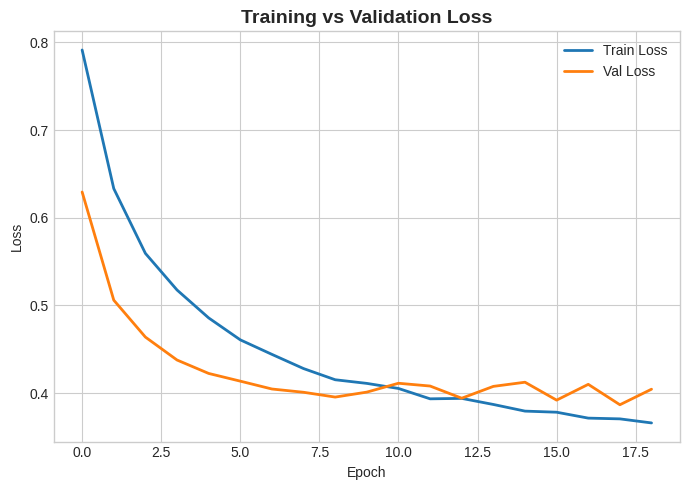

In [20]:
# 1. Training & Validation Loss
plt.figure(figsize=(7, 5))
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
plt.title('Training vs Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

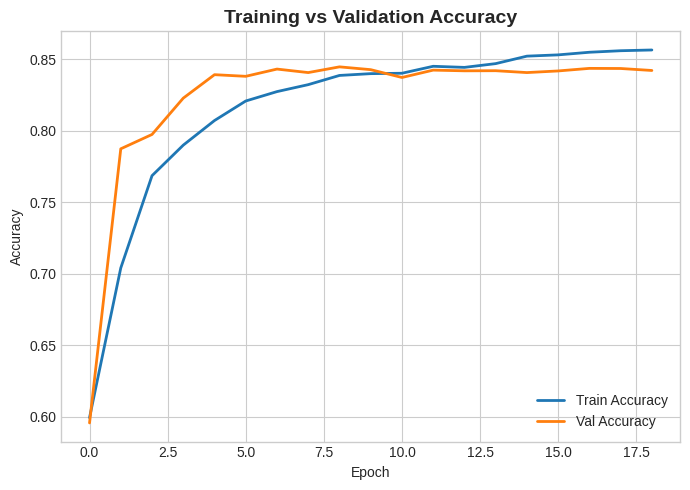

In [21]:
# 2. Training & Validation Accuracy
plt.figure(figsize=(7, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
plt.title('Training vs Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

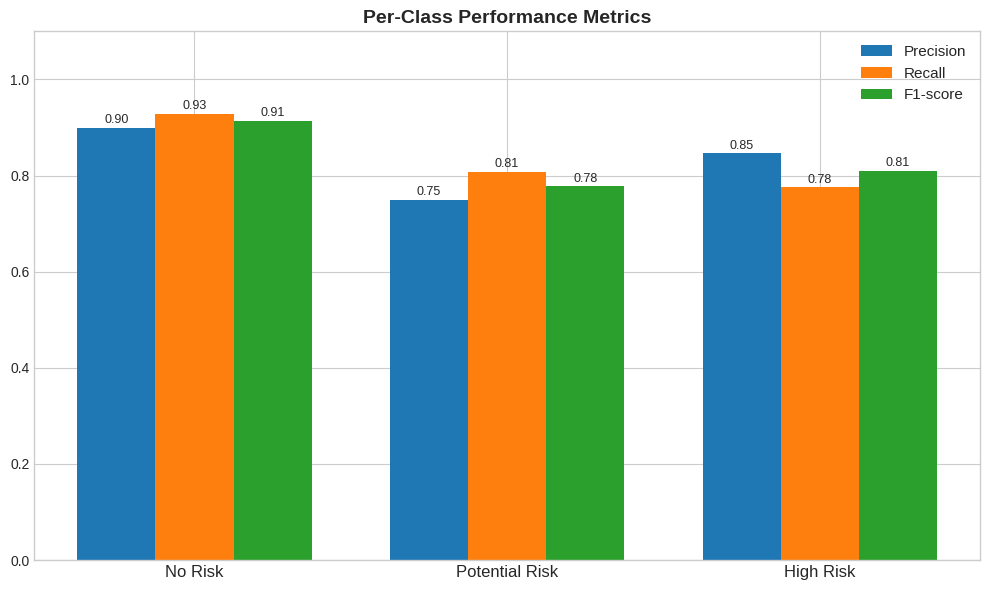

In [22]:
# 3. Per-Class Precision / Recall / F1
metrics_names = ['precision', 'recall', 'f1-score']
fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(CLASS_NAMES))
width = 0.25

for i, metric in enumerate(metrics_names):
    values = [test_metrics[c][metric] for c in CLASS_NAMES]
    bars = ax.bar([xi + i * width for xi in x], values, width, label=metric.capitalize())
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.2f}', ha='center', fontsize=9)

ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(DISPLAY_NAMES, fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_title('Per-Class Performance Metrics', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

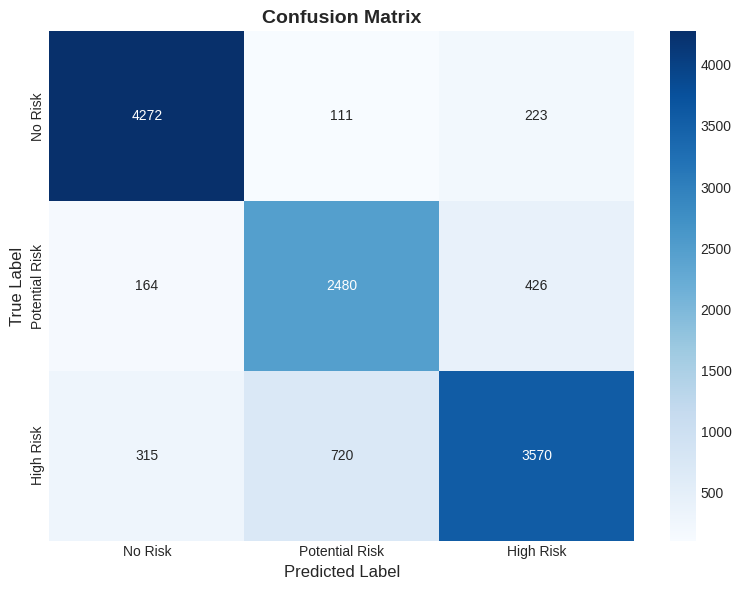

In [23]:
# 4. Confusion Matrix Heatmap
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=DISPLAY_NAMES, yticklabels=DISPLAY_NAMES, ax=ax)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()